# Ames Housing Data - Exploratory Data Analysis & Modeling

## 1. Dataset Introduction

This dataset is the **Ames Housing Dataset**, originally compiled by Dean De Cock for use in data science education. It contains **2930 residential homes** sold in Ames, Iowa, between 2006 and 2010.  
It is a modern, richer alternative to the classic Boston Housing dataset.

---

## 2. Features Overview 

The dataset contains **81 features (columns)** and **1 target variable**: SalePrice.

### Target variable (what we want to understand/predict)
| Column | Description |
|--------|-------------|
| SalePrice | Sale price of the house in dollars (our target) |

### Feature categories

#### Identification & general
- Order, PID – just row/parcel ID 
- MS SubClass, MS Zoning – type of dwelling and zoning classification

#### Lot & land
- Lot Frontage – linear feet of street connected to property 
- Lot Area – total lot size in square feet
- Lot Shape, Land Slope – shape and slope of the land

#### House structure & quality
- Overall Qual – rates overall material & finish (1-10)
- Overall Cond – rates overall condition (1-10)
- Year Built, Year Remod/Add – construction and remodel year
- Exterior 1st, Roof Style, Foundation – construction materials & style

#### Basement
- Bsmt Qual, Bsmt Cond – basement quality/condition 
- BsmtFin SF 1, Total Bsmt SF – finished and total basement area

#### Living area & rooms
- Gr Liv Area – above-grade living area square footage
- TotRms AbvGrd, Bedroom AbvGr – number of rooms & bedrooms
- Full Bath, Half Bath – bathroom counts

#### Kitchen
- Kitchen Qual – kitchen quality (ordinal)
- Kitchen AbvGr – number of kitchens above grade 

#### Garage
- Garage Type, Garage Finish – garage construction 
- Garage Cars, Garage Area – capacity and size

#### Extra amenities
- Fireplaces, Fireplace Qu – number and quality of fireplaces
- Pool Area, Pool QC – swimming pool 
- Wood Deck SF, Open Porch SF, Screen Porch – outdoor living areas

#### Location & neighborhood
- Neighborhood – categorical
- Condition 1, Condition 2 – proximity to main road or railroad

#### Temporal features
- Mo Sold, Yr Sold – sale month and year
- Sale Type, Sale Condition – type and condition of sale

## Libraries

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt

## Loading the Dataset

In [6]:
data = pd.read_csv(r'D:\sharif\ADS\assignment1\AmesHousing.csv')
data.shape

(2930, 82)

# Exploratory Data Analysis(EDA)

### Getting some insights

In [7]:
data.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

#### 

#### Observing columns thst have null value

In [9]:

missing_counts = data.isnull().sum()
missing_percent = (missing_counts / len(data)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_counts, 'Missing Percent': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Percent', ascending=False)
missing_df.head(81)

,Missing Count,Missing Percent
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Qual,159,5.426621
Garage Cond,159,5.426621
Garage Yr Blt,159,5.426621


In [10]:
data.duplicated().sum()

np.int64(0)

There is no duplecated rows in dataset

In [11]:
data.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


### Analysing distribution of SalePrice (goal feature)

C:\Users\kavoshrayan\AppData\Local\Temp\ipykernel_4768\4275277785.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


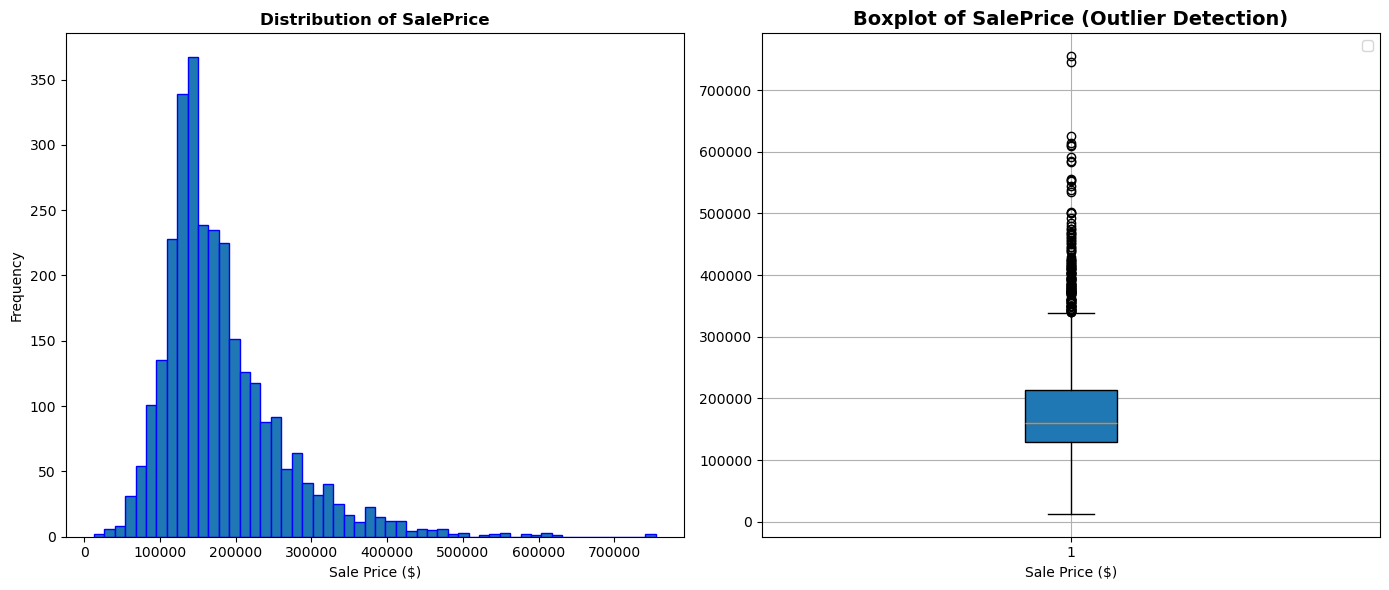

In [12]:
fig, axes = plt.subplots(1,2, figsize=(14,6))


num_bins_sqrt = int(np.sqrt(len(data)))

axes[0].hist(data['SalePrice'], bins=num_bins_sqrt, edgecolor='blue')
axes[0].set_title('Distribution of SalePrice', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(x=data['SalePrice'], patch_artist=True, showfliers=True)
axes[1].set_title('Boxplot of SalePrice (Outlier Detection)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sale Price ($)')

plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

Right-skewed distribution for Saleprice =>  most houses are moderately priced.

Mean: ~$180,000, Median: ~$160,000 fro SalePrice.

There are a number of expensive houses (over $400,000) as outliers.

In [13]:
Q1 = data['SalePrice'].quantile(0.25)
Q3 = data['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['SalePrice'] < lower_bound) | (data['SalePrice'] > upper_bound)]
print(f"Number of outliers in SalePrice: {len(outliers)}")
print(f"Percentage: {len(outliers)/len(data)*100:.2f}%")
print("\nCharacteristics of outlier houses:")
print(outliers[['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Neighborhood', 'Year Built']].head(10))

Number of outliers in SalePrice: 137
Percentage: 4.68%

Characteristics of outlier houses:
     SalePrice  Overall Qual  Gr Liv Area Neighborhood  Year Built
15      538000             8         3279      StoneBr        2003
17      394432             9         1856      StoneBr        2010
36      376162             9         2334      NridgHt        2009
38      395192             9         1940      NridgHt        2009
44      611657             9         2364      NridgHt        2009
46      500000             9         2696      NridgHt        2003
60      355000             8         2475      NoRidge        1998
65      410000             8         3238      NoRidge        1995
91      362500             8         2349      NoRidge        1993
321     378500             9         2018       Timber        2008


### Investigation of the effect of most important numeric features on SalePrice

C:\Users\kavoshrayan\AppData\Local\Temp\ipykernel_4768\1048018421.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


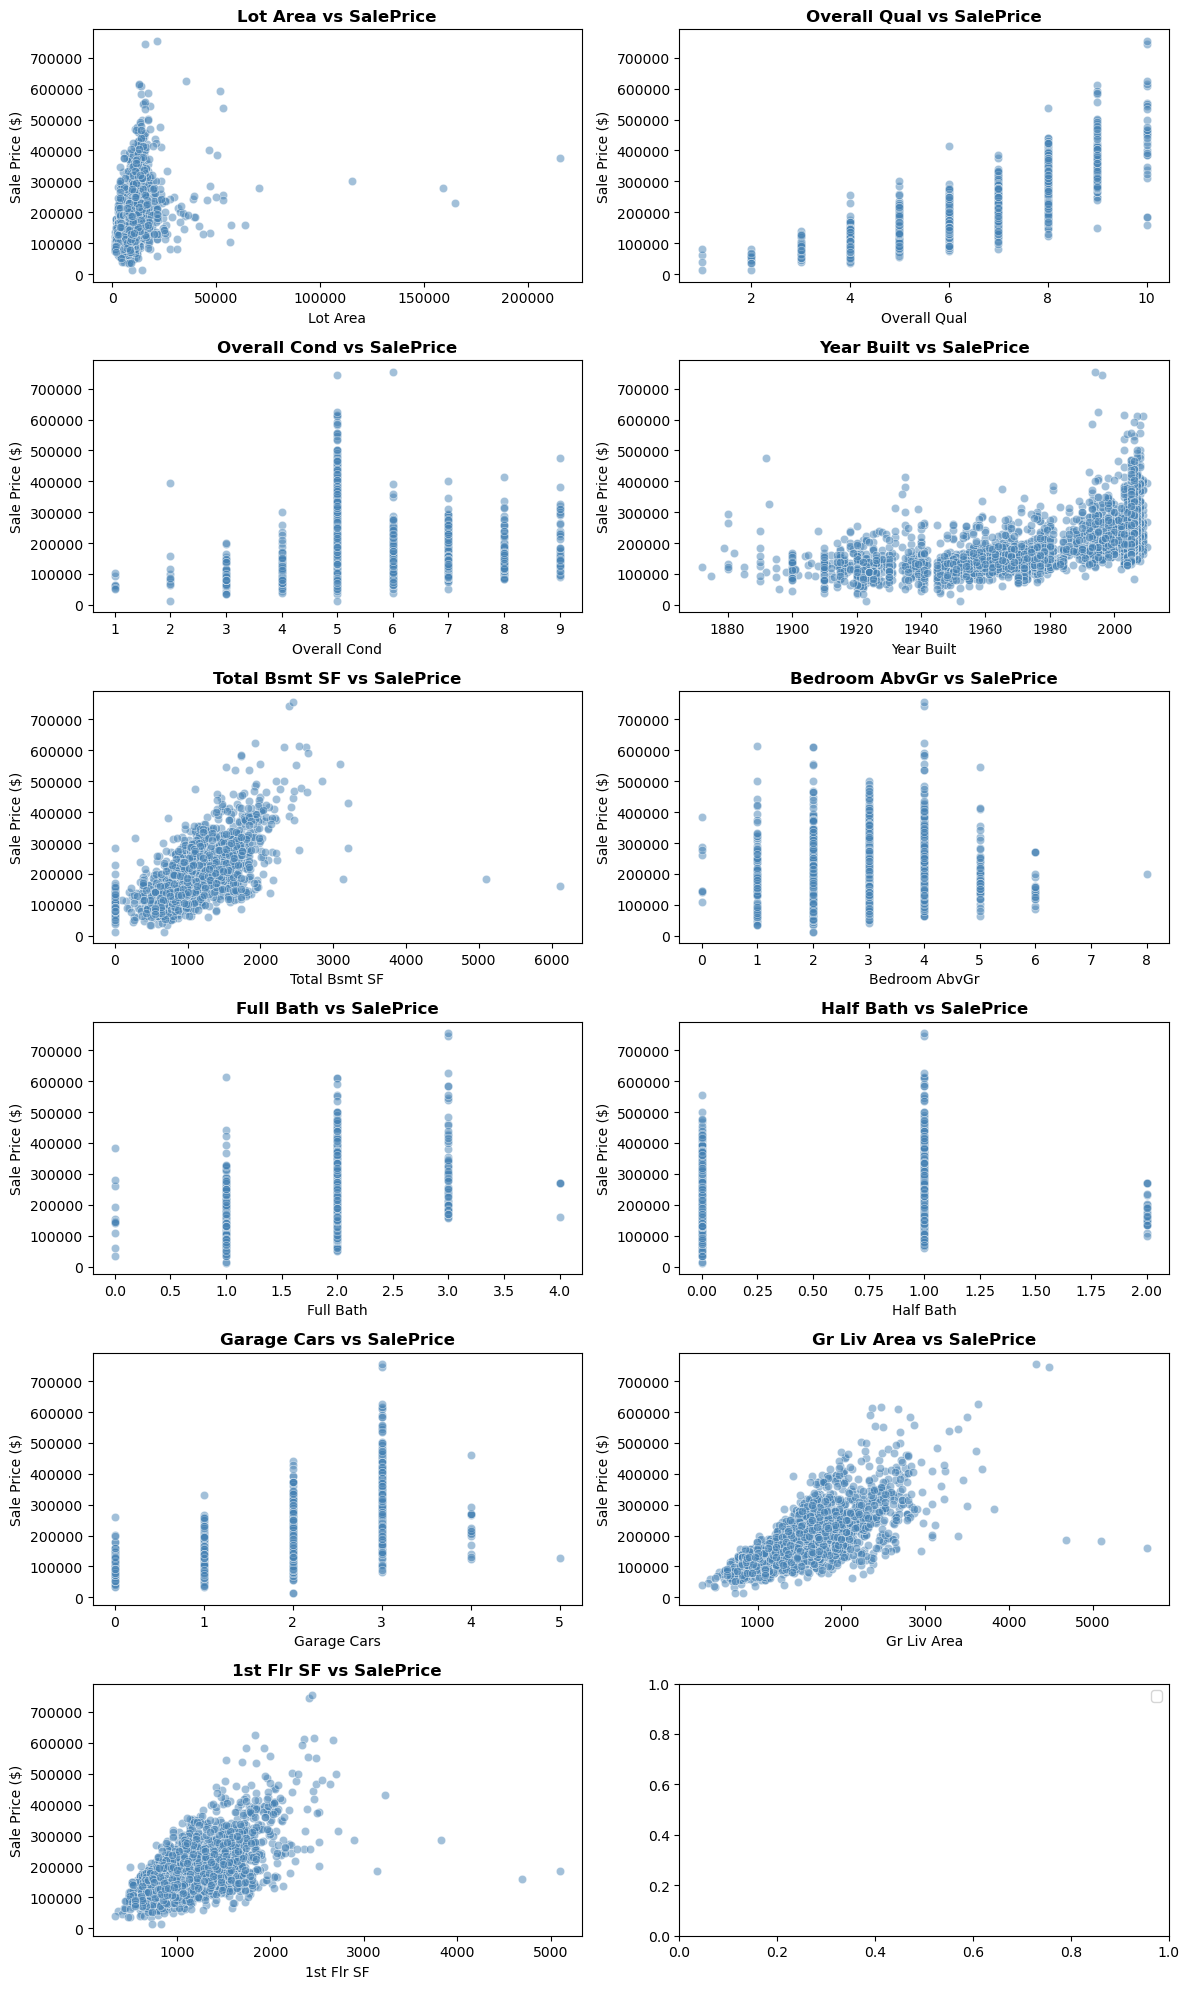

In [14]:
import math

important_numeric_features = ['Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Total Bsmt SF', 
                    'Bedroom AbvGr', 'Full Bath', 'Half Bath', 'Garage Cars', 'Gr Liv Area', '1st Flr SF']

fig, axes = plt.subplots(math.ceil(len(important_numeric_features)/2), 2, figsize=(12,20))
axes = axes.flatten()

for i, feature in enumerate(important_numeric_features):
    valid_data = data[[feature, 'SalePrice']].dropna()
    x = valid_data[feature]
    y = valid_data['SalePrice']

    axes[i].scatter(x, y, alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.5)

    axes[i].set_title(f'{feature} vs SalePrice', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Sale Price ($)')
    

plt.tight_layout()
plt.legend()
plt.show()

Overall Qual : Highest correlation – house quality is the most important factor determining price.

Gr Liv Area : Living area has a very strong impact on price.

Garage Cars/Area : Larger garage → higher price.

Total Bsmt SF : Larger basement adds value.

Year Built : Newer homes are typically more expensive.

Lot Area : Weak correlation – larger lot doesn't always mean higher price (location matters more).

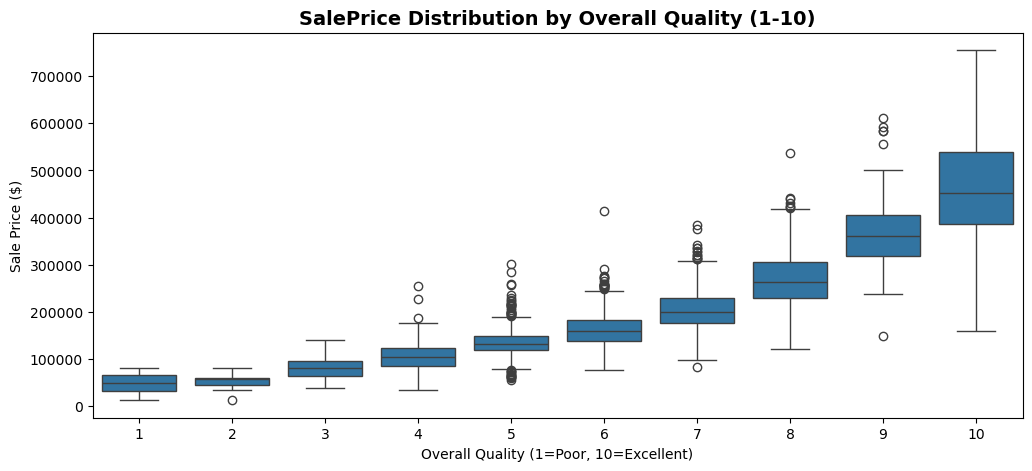

,Overall Qual,mean,median,count
0,1,48725.000000,50150.0,4
1,2,52325.307692,57625.0,13
2,3,83185.975000,81200.0,40
3,4,106485.097345,105000.0,226
4,5,134752.516364,133000.0,825
5,6,162130.318306,159500.0,732
6,7,205025.760797,200000.0,602
7,8,270913.594286,264530.5,350
8,9,368336.766355,360000.0,107
9,10,450217.322581,451950.0,31


In [15]:
plt.figure(figsize=(12, 5))
sns.boxplot(x='Overall Qual', y='SalePrice', data=data)
plt.title('SalePrice Distribution by Overall Quality (1-10)', fontsize=14, fontweight='bold')
plt.xlabel('Overall Quality (1=Poor, 10=Excellent)')
plt.ylabel('Sale Price ($)')
plt.show()

qual_stats = data.groupby('Overall Qual')['SalePrice'].agg(['mean', 'median', 'count']).reset_index()
qual_stats

C:\Users\kavoshrayan\AppData\Local\Temp\ipykernel_4768\3604846649.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


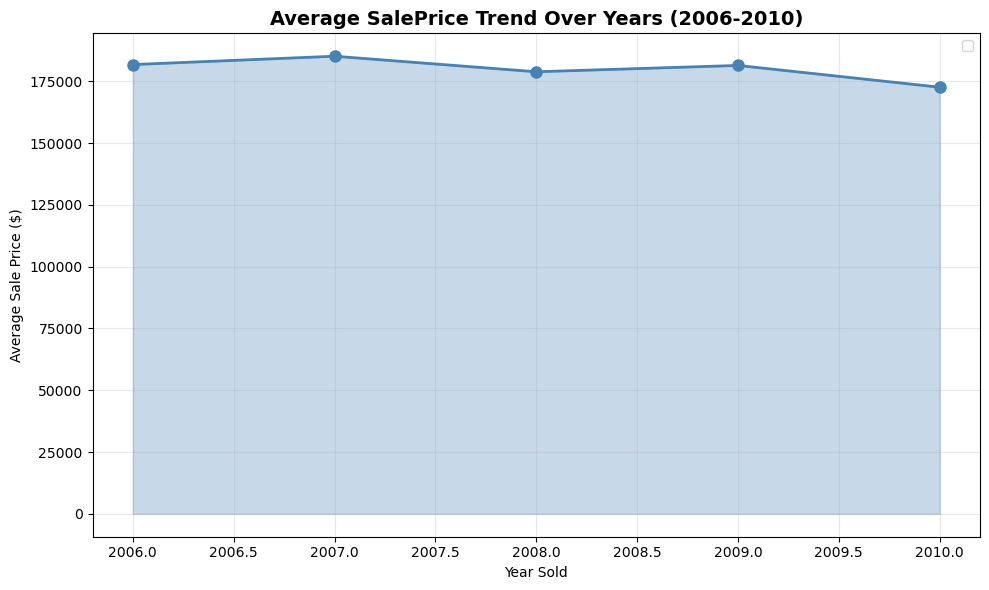

In [16]:
yearly_prices = data.groupby('Yr Sold')['SalePrice'].mean()

plt.figure(figsize=(10, 6))
plt.plot(yearly_prices.index, yearly_prices.values, marker='o', linewidth=2, markersize=8, color='steelblue')
plt.fill_between(yearly_prices.index, yearly_prices.values, alpha=0.3, color='steelblue')
plt.title('Average SalePrice Trend Over Years (2006-2010)', fontsize=14, fontweight='bold')
plt.xlabel('Year Sold')
plt.ylabel('Average Sale Price ($)')
plt.grid(True, alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()

### Investigation of the effect of most important categorical features on SalePrice

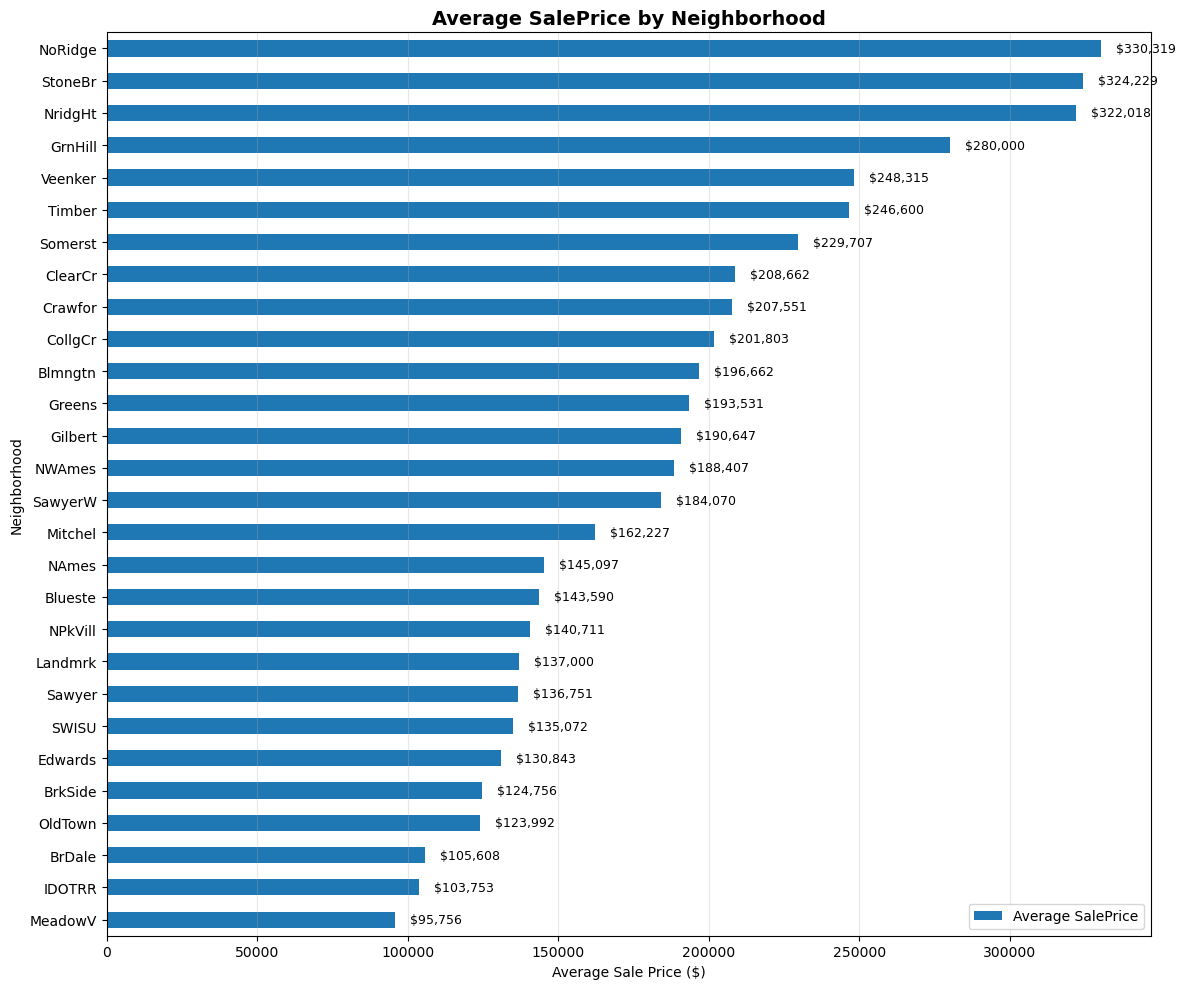

In [17]:
neigh_price_mean = data.groupby('Neighborhood')['SalePrice'].mean().sort_values()

plt.figure(figsize=(12,10))

neigh_price_mean.plot(kind='barh')
plt.title('Average SalePrice by Neighborhood', fontsize=14, fontweight='bold')
plt.xlabel('Average Sale Price ($)')
plt.ylabel('Neighborhood')
plt.grid(axis='x', alpha=0.3)

for i,v in enumerate(neigh_price_mean):
    plt.text(v + 5000, i, f'${v:,.0f}', va='center', fontsize=9)

plt.legend(['Average SalePrice'])
plt.tight_layout()
plt.show()


#### Interactive charts using Plotly

To better understand the relationship between living area and sale price across different neighborhoods.

In [234]:
import plotly.express as px

fig = px.scatter(data, 
                 x="Gr Liv Area", 
                 y="SalePrice", 
                 color="Neighborhood",
                 title="Living Area vs SalePrice by Neighborhood",
                 hover_data=["Overall Qual"])
fig.show()

- There is a linear realationship between Living Area and SalePrice.
- Each Neighborhood has houses with different living area.
- But SalePrice for each Neighborhood is in a small range.(SalePrices in each Neighborhood are similar)

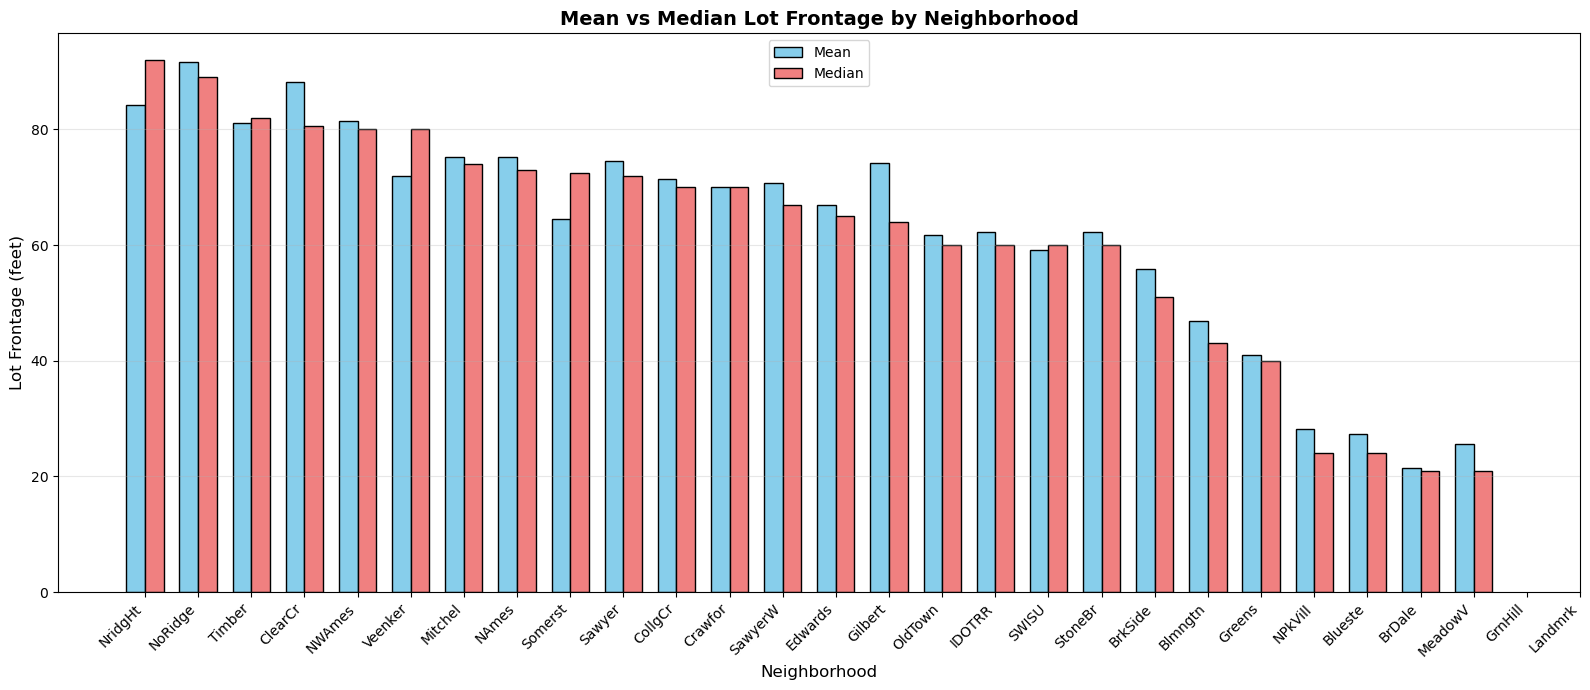

In [18]:
neigh_stats = data.groupby('Neighborhood')['Lot Frontage'].agg(['mean', 'median', 'count'])
neigh_stats = neigh_stats.sort_values('median', ascending=False)

fig, ax = plt.subplots(figsize=(16, 7))

x = np.arange(len(neigh_stats))
width = 0.35

bars1 = ax.bar(x - width/2, neigh_stats['mean'], width, label='Mean', color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, neigh_stats['median'], width, label='Median', color='lightcoral', edgecolor='black')

ax.set_xlabel('Neighborhood', fontsize=12)
ax.set_ylabel('Lot Frontage (feet)', fontsize=12)
ax.set_title('Mean vs Median Lot Frontage by Neighborhood', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(neigh_stats.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

- Lot Frontage varies significantly by neighborhood .
-Wealthy neighborhoods (e.g., NridgHt, StoneBr) have wider lots.
- Cheaper neighborhoods (e.g., MeadowV, BrDale) have narrower lots.

In [19]:
quality_cols = ['Kitchen Qual', 'Bsmt Qual', 'Overall Qual']

print(data['Kitchen Qual'].unique())
print(data['Bsmt Qual'].unique())
print(data['Overall Qual'].unique())

['TA' 'Gd' 'Ex' 'Fa' 'Po']
['TA' 'Gd' 'Ex' nan 'Fa' 'Po']
[ 6  5  7  8  9  4  3  2 10  1]


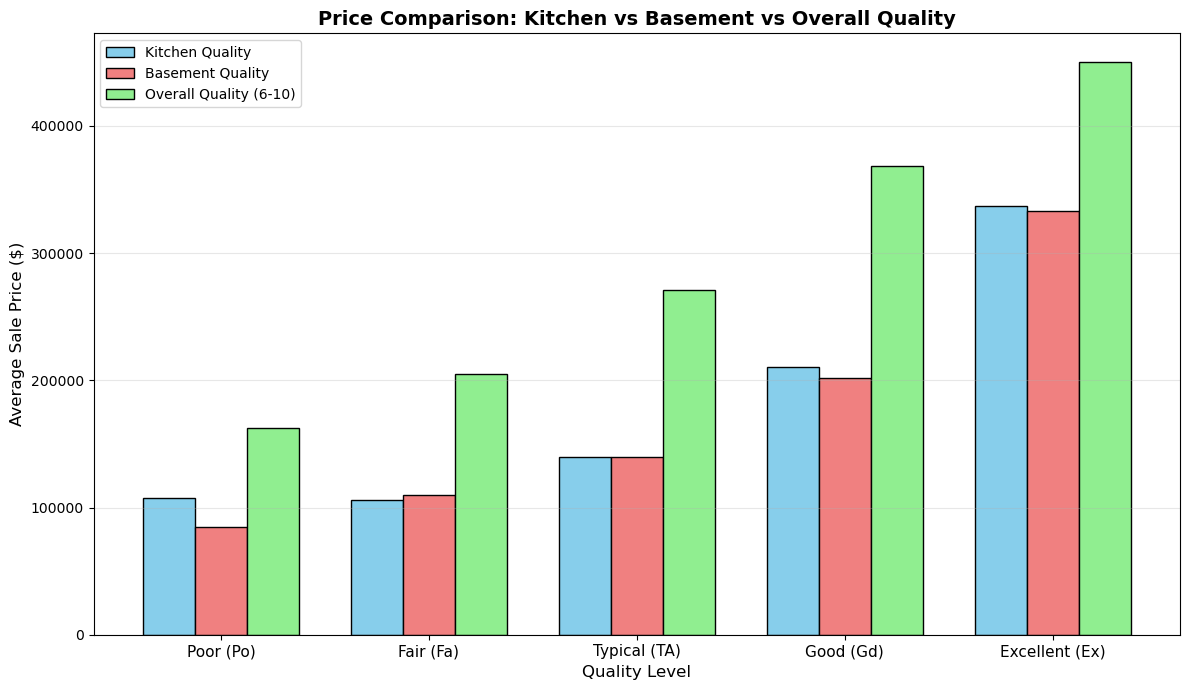

In [20]:
quality_order = ['Po', 'Fa', 'TA', 'Gd', 'Ex']
quality_labels = ['Poor (Po)', 'Fair (Fa)', 'Typical (TA)', 'Good (Gd)', 'Excellent (Ex)']

kitchen_values = [data[data['Kitchen Qual'] == q]['SalePrice'].mean() if q in data['Kitchen Qual'].values else 0 for q in quality_order]
bsmt_values = [data[data['Bsmt Qual'] == q]['SalePrice'].mean() if q in data['Bsmt Qual'].values else 0 for q in quality_order]
overall_values = [data[data['Overall Qual'] == i]['SalePrice'].mean() for i in range(6, 11)]

x = np.arange(len(quality_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width, kitchen_values, width, label='Kitchen Quality', color='skyblue', edgecolor='black')
bars2 = ax.bar(x, bsmt_values, width, label='Basement Quality', color='lightcoral', edgecolor='black')
bars3 = ax.bar(x + width, overall_values, width, label='Overall Quality (6-10)', color='lightgreen', edgecolor='black')

ax.set_xlabel('Quality Level', fontsize=12)
ax.set_ylabel('Average Sale Price ($)', fontsize=12)
ax.set_title('Price Comparison: Kitchen vs Basement vs Overall Quality', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(quality_labels, fontsize=11)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

- Overall Quality is the strongest predictor of SalePrice. Kitchen Quality and Basement Quality have similar but weaker positive effects. 

- The linear and consistent relationship across all quality levels confirms the reliability of the data.

- The impact of Overall Qual is greater than the sum of Kitchen Qual and Bsmt Qual combined.
This means overall quality is not just the sum of its parts – it captures something unique about the house (e.g., design, materials, structure)



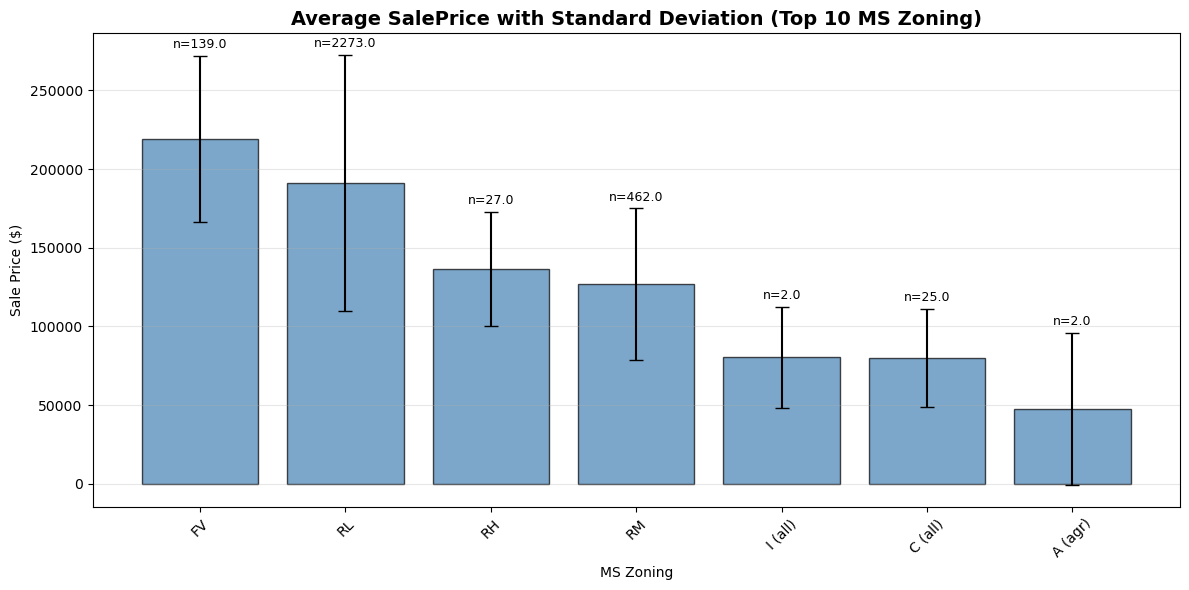

In [21]:
top10_neigh = data.groupby('MS Zoning')['SalePrice'].mean().nlargest(10).index
neigh_stats = data[data['MS Zoning'].isin(top10_neigh)].groupby('MS Zoning')['SalePrice'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(neigh_stats.index, neigh_stats['mean'], yerr=neigh_stats['std'], 
        capsize=5, color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Average SalePrice with Standard Deviation (Top 10 MS Zoning)', fontsize=14, fontweight='bold')
plt.xlabel('MS Zoning')
plt.ylabel('Sale Price ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for i, (idx, row) in enumerate(neigh_stats.iterrows()):
    plt.text(i, row['mean'] + row['std'] + 5000, f'n={row["count"]}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

This bar chart shows the average SalePrice for the top 10 most expensive neighborhoods, with error bars representing ±1 standard deviation. The error bars indicate the variability of prices within each neighborhood – wider bars mean more price variation.

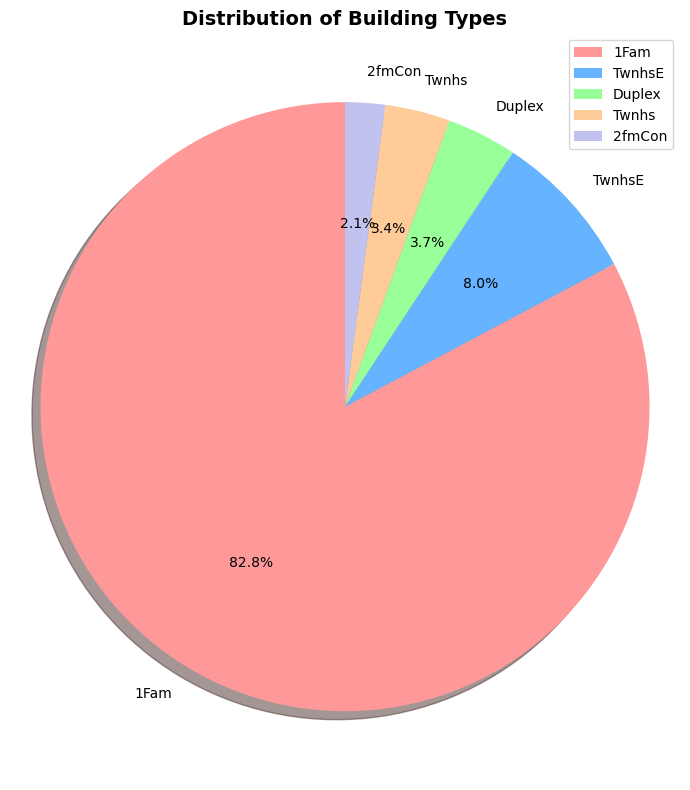

In [22]:
bldg_counts = data['Bldg Type'].value_counts()

plt.figure(figsize=(7, 8))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']

plt.pie(bldg_counts.values, labels=bldg_counts.index, autopct='%1.1f%%', 
        colors=colors, shadow=True, startangle=90)
plt.title('Distribution of Building Types', fontsize=14, fontweight='bold')
plt.axis('equal') 
plt.tight_layout()
plt.legend()
plt.show()

82% of homes are single-family homes (1Fam)

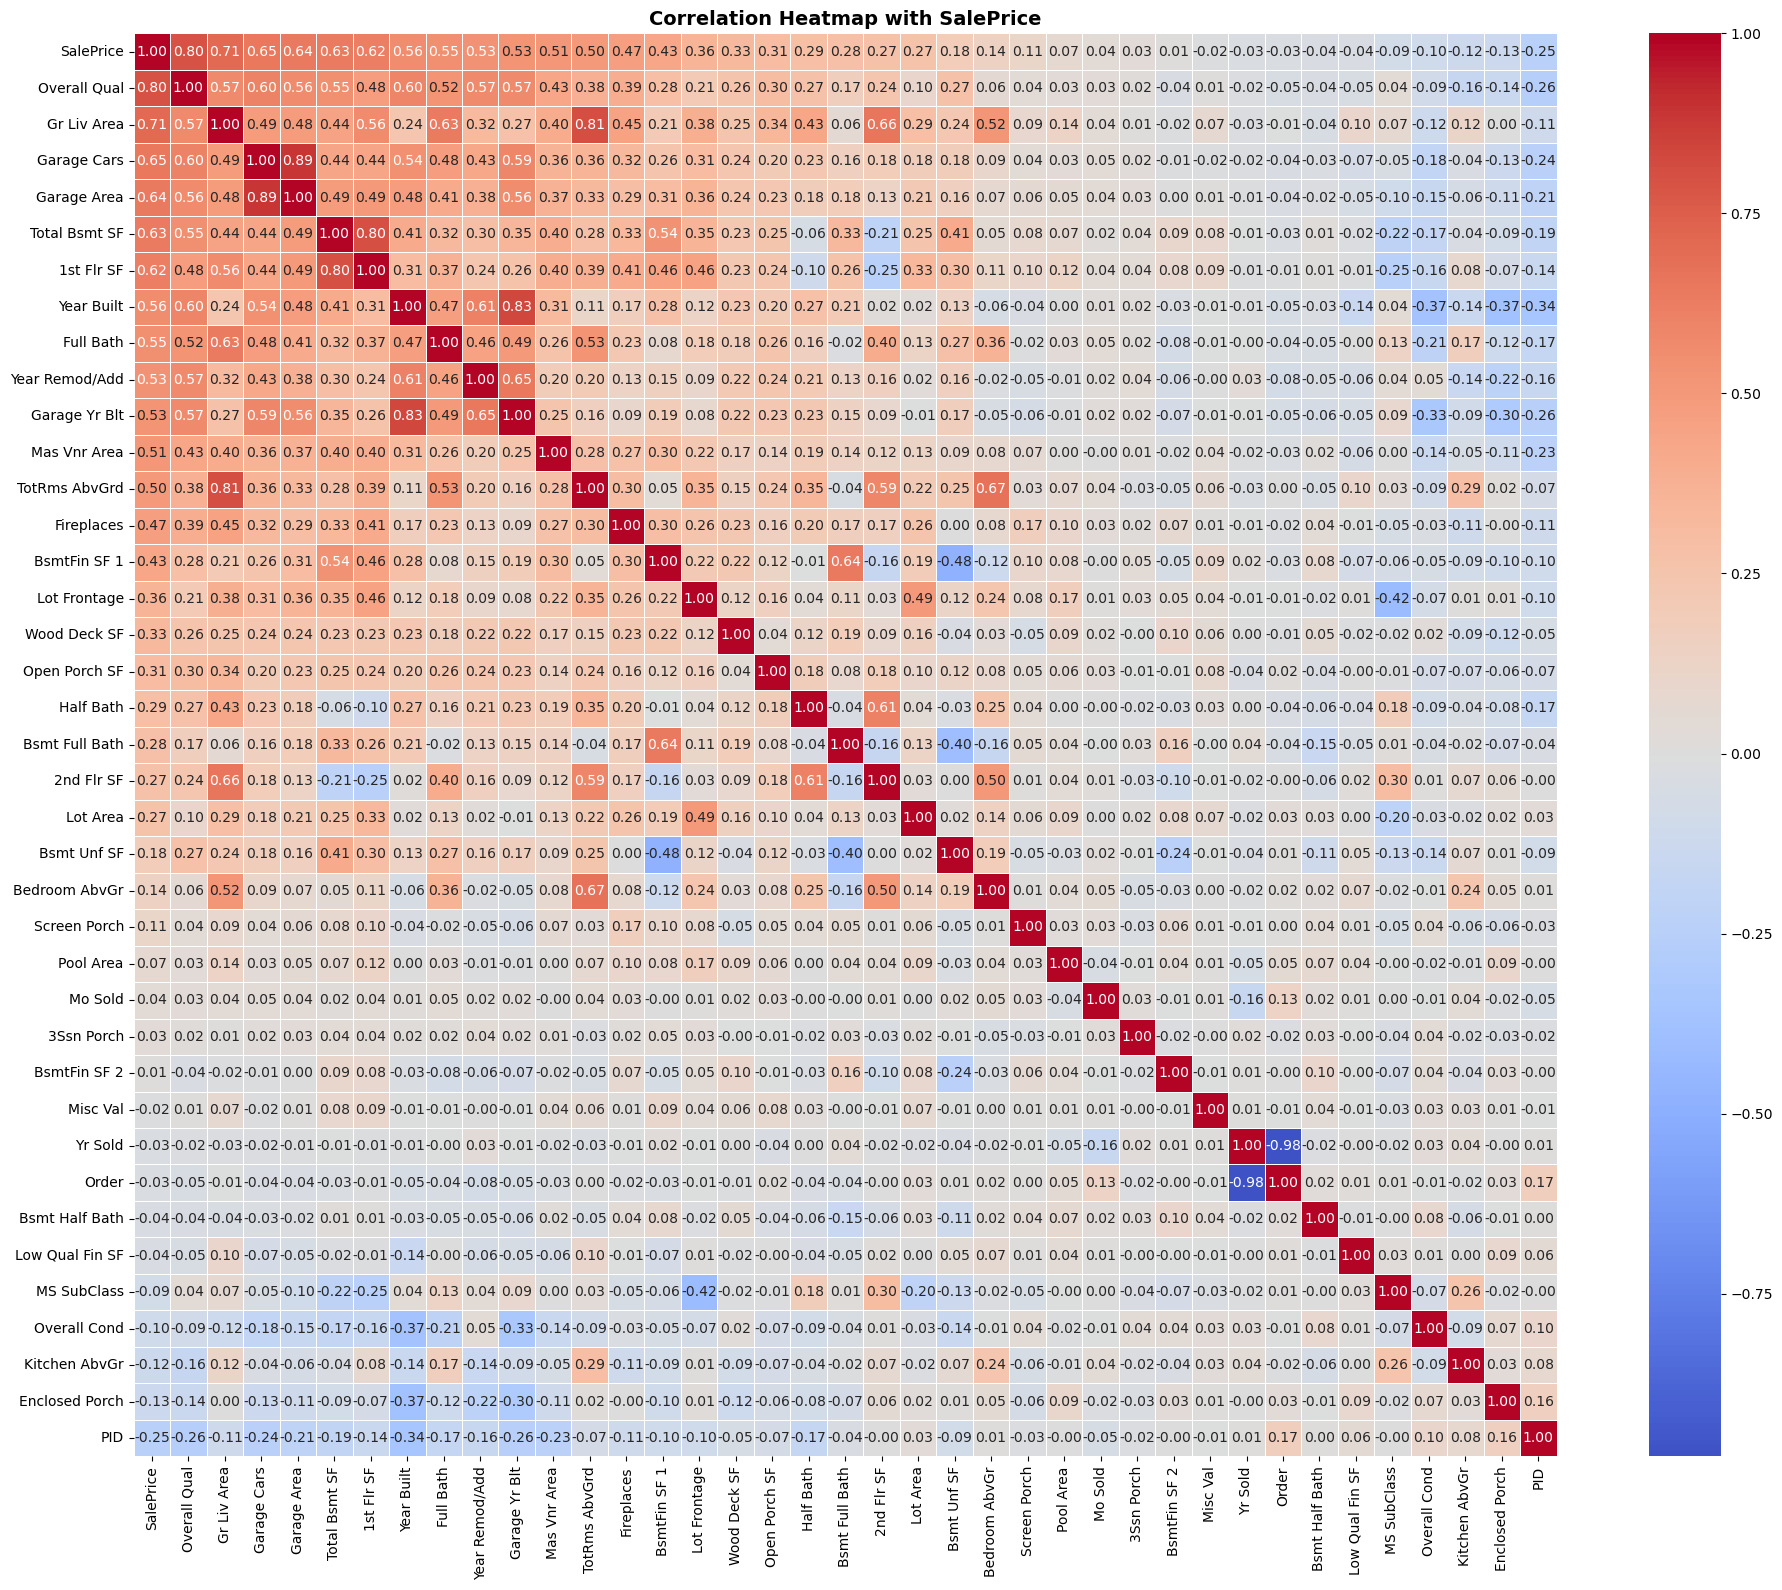

In [23]:
numeric_columns = data.select_dtypes(include=[np.number])
corr_matrix = numeric_columns.corr()

price_corr = corr_matrix['SalePrice'].sort_values(ascending=False)

top_features = price_corr.index.tolist()
plt.figure(figsize=(20, 16))
sns.heatmap(data[top_features].corr(), annot=True, cmap='coolwarm', 
            center=0, fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Heatmap with SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Data Cleaning

In [202]:
data_clean = data.copy()

#### Dropping Useless Columns

- Order, PID  are random identifiers with no predictive value , so remove them.

In [203]:
usless_col = ['Order', 'PID']

data_clean = data_clean.drop(columns=usless_col, axis=1)
data_clean.shape

(2930, 80)

Finding numerical useless columns(columns with no predictive value)

In [204]:
stats = data_clean.describe()

suspicious_cols = []

for col in stats.columns:
    q25 = stats.loc['25%', col]
    q50 = stats.loc['50%', col]
    q75 = stats.loc['75%', col]
    
    reasons = []
    
    # (Q1 = Q2 = Q3) => most af values are similar
    if q25 == q50 == q75:
        reasons.append(f"all values are {q25:.0f} (no variation)")
        
    if reasons:
        suspicious_cols.append({
            'Column': col,
            'Issues': ', '.join(reasons)
        })

if suspicious_cols:
    suspicious_df = pd.DataFrame(suspicious_cols)
    print(suspicious_df.to_string(index=False))

         Column                          Issues
   BsmtFin SF 2 all values are 0 (no variation)
Low Qual Fin SF all values are 0 (no variation)
 Bsmt Half Bath all values are 0 (no variation)
  Kitchen AbvGr all values are 1 (no variation)
 Enclosed Porch all values are 0 (no variation)
     3Ssn Porch all values are 0 (no variation)
   Screen Porch all values are 0 (no variation)
      Pool Area all values are 0 (no variation)
       Misc Val all values are 0 (no variation)


In [205]:
columns_to_drop = [
    'BsmtFin SF 2', 'Low Qual Fin SF', 'Bsmt Half Bath', 
    'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 
    'Pool Area', 'Misc Val'
]

for col in columns_to_drop:
    if col in data_clean.columns:
        zero_pct = (data_clean[col] == 0).mean() * 100
        print(f"{col}: {zero_pct:.1f}% are zero")    

BsmtFin SF 2: 88.0% are zero
Low Qual Fin SF: 98.6% are zero
Bsmt Half Bath: 94.0% are zero
Enclosed Porch: 84.3% are zero
3Ssn Porch: 98.7% are zero
Screen Porch: 91.3% are zero
Pool Area: 99.6% are zero
Misc Val: 96.5% are zero


Drop columns that have >90% zero values and provide almost no predictive power.

In [206]:
columns_to_drop.remove('Enclosed Porch')
columns_to_drop.remove('BsmtFin SF 2')

data_clean = data_clean.drop(columns=columns_to_drop, errors='ignore')

In [207]:
data_clean.shape

(2930, 74)

Remove columns with more than 80% missing value

- missing > 80% => too sparse to be useful

In [208]:
high_miss_col = missing_df[missing_df['Missing Percent'] > 80].index.tolist()

data_clean = data_clean.drop(columns=high_miss_col, axis=1)

print(f"columns with more than 80% missing value : {high_miss_col}")
data_clean.shape

columns with more than 80% missing value : ['Pool QC', 'Misc Feature', 'Alley', 'Fence']


(2930, 70)

Check some sparse categorical features.

In [209]:
suspicious_cols = ['Street', 'Utilities', 'Roof Matl', 'Heating']

for col in suspicious_cols:
    if col not in data_clean.columns:
        continue
    
    stats = data_clean.groupby(col)['SalePrice'].agg(['mean', 'count']).round(0)
    stats.columns = ['Avg_Price', 'Count']
    stats['Percent'] = (stats['Count'] / len(data_clean) * 100).round(1)
    stats = stats.sort_values('Avg_Price', ascending=False)

    print(f" {col}")
    for idx, row in stats.iterrows():
        print(f"   • {idx:15s} | Avg Price: ${row['Avg_Price']:>10,.0f} | Count: {row['Count']:>4} ({row['Percent']:>5.1f}%)")

 Street
   • Pave            | Avg Price: $   181,101 | Count: 2918.0 ( 99.6%)
   • Grvl            | Avg Price: $   106,663 | Count: 12.0 (  0.4%)
 Utilities
   • AllPub          | Avg Price: $   180,875 | Count: 2927.0 ( 99.9%)
   • NoSeWa          | Avg Price: $   137,500 | Count:  1.0 (  0.0%)
   • NoSewr          | Avg Price: $    86,312 | Count:  2.0 (  0.1%)
 Roof Matl
   • WdShngl         | Avg Price: $   374,357 | Count:  7.0 (  0.2%)
   • Membran         | Avg Price: $   241,500 | Count:  1.0 (  0.0%)
   • WdShake         | Avg Price: $   238,444 | Count:  9.0 (  0.3%)
   • Tar&Grv         | Avg Price: $   185,141 | Count: 23.0 (  0.8%)
   • CompShg         | Avg Price: $   180,114 | Count: 2887.0 ( 98.5%)
   • Metal           | Avg Price: $   180,000 | Count:  1.0 (  0.0%)
   • ClyTile         | Avg Price: $   160,000 | Count:  1.0 (  0.0%)
   • Roll            | Avg Price: $   137,000 | Count:  1.0 (  0.0%)
 Heating
   • GasA            | Avg Price: $   181,594 | Count: 288

- Street: 2 categories, clear price difference => Keep
- Utilities: Rare categories have <5 houses => Drop
- Roof Matl: 98.7% are 'CompShg', but other categories show price differences and arent similar => Keep
- Heating: 98.5% are 'GasA', but other types show different prices => Group rare into 'Other'

In [210]:
data_clean = data_clean.drop(columns=['Utilities'])

rare_heating = ['Grav', 'Wall', 'Floor']
data_clean['Heating'] = data_clean['Heating'].apply(
        lambda x: 'Other' if x in rare_heating else x
    )

print(f"  categories: {data_clean['Heating'].unique()}")
print(data_clean.shape)

  categories: ['GasA' 'GasW' 'Other' 'OthW']
(2930, 69)


In [211]:
data_clean[(data['Exterior 2nd'] == data['Exterior 1st'])].shape

(2488, 69)

- Exterior 2nd: Redundant with Exterior 1st => Drop

In [212]:
data_clean = data_clean.drop(columns=['Exterior 2nd'])
data_clean.shape

(2930, 68)

**1-Fill missing Lot Frontage with neighborhood median**
   - Maintains the local pattern of each neighborhood
   - Preserves the relationship between lot width and location

**2-Fill missing Lot Frontage  with neighborhood median of similar neighborhood for neighborhoods that have no Lot Frontage**

In [213]:
# 1:
data_clean['Lot Frontage'] = data_clean.groupby('Neighborhood')['Lot Frontage'].transform(lambda x: x.fillna(x.median()))

# 2:
# average of SalePrice
neigh_avg_price = data_clean.groupby('Neighborhood')['SalePrice'].mean().sort_values()

# finding neighborhoods with no Lot Frontage
problem_neigh = data_clean[data_clean['Lot Frontage'].isnull()]['Neighborhood'].unique()
print(f"\nProblematic neighborhoods (no Lot Frontage data): {problem_neigh}")

# finding simalr neighborhood on the basis of average SalePrice
for neigh in problem_neigh:
    if neigh in neigh_avg_price.index:
        target_price = neigh_avg_price[neigh]
    else:
        target_price = data_clean[data_clean['Neighborhood'] == neigh]['SalePrice'].mean()
    
    price_diff = (neigh_avg_price - target_price).abs()
    
    if neigh in price_diff.index:
        price_diff = price_diff.drop(neigh)
    
    closest_neigh = price_diff.idxmin()
    closest_price = neigh_avg_price[closest_neigh]
    
    impute_value = data_clean[data_clean['Neighborhood'] == closest_neigh]['Lot Frontage'].median()
    
    data_clean.loc[data_clean['Neighborhood'] == neigh, 'Lot Frontage'] = \
        data_clean.loc[data_clean['Neighborhood'] == neigh, 'Lot Frontage'].fillna(impute_value)
    

print(data_clean['Lot Frontage'].isnull().sum())
print(data_clean.shape)


Problematic neighborhoods (no Lot Frontage data): ['GrnHill' 'Landmrk']
0
(2930, 68)


For houses **without a garage**, all garage-related features are set to:

- Categorical features **(Garage Type, Garage Finish, Garage Cond, Garage Qual)** => None 

- Numeric features **(Garage Cars, Garage Area, Garage Yr Blt)** => 0 

- If a house has a garage but year is missing → fill with **Year Built**   (garage built with house)


In [214]:
garage_features = ['Garage Type', 'Garage Yr Blt', 'Garage Finish', 
                   'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond']

garage_yr_missing = data_clean[data_clean['Garage Yr Blt'].isnull()]

# houses with no garage
no_garage_mask = (data_clean['Garage Type'].isnull()) | (data_clean['Garage Area'] == 0)

for col in garage_features:
    if col in ['Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']:
        data_clean.loc[no_garage_mask, col] = 'None'
    else:
        data_clean.loc[no_garage_mask, col] = 0

# houses that have garage but Garage Yr Blt is missing
missing_mask = data_clean['Garage Yr Blt'].isnull()

if len(missing_mask) > 0:
    data_clean.loc[missing_mask, 'Garage Yr Blt'] = data_clean.loc[missing_mask, 'Year Built']

In [215]:
print(data_clean['Garage Type'].isnull().sum())
print(data_clean.shape)

0
(2930, 68)


In [216]:
data_clean[data_clean['Garage Qual'].isnull()][['Garage Type','Garage Qual','Garage Cond','Garage Finish','Garage Area','Garage Cars']]

,Garage Type,Garage Qual,Garage Cond,Garage Finish,Garage Area,Garage Cars
1356,Detchd,NaN,NaN,NaN,360.0,1.0
2236,Detchd,NaN,NaN,NaN,NaN,NaN


In [217]:
# fill this above rows with normal and usual values
data_clean.loc[1356, 'Garage Qual'] = 'TA'
data_clean.loc[1356, 'Garage Cond'] = 'TA'
data_clean.loc[1356, 'Garage Finish'] = 'Unf'

data_clean.loc[2236, 'Garage Qual'] = 'TA'
data_clean.loc[2236, 'Garage Cond'] = 'TA'
data_clean.loc[2236, 'Garage Finish'] = 'Unf'
data_clean.loc[2236, 'Garage Area'] = 300
data_clean.loc[2236, 'Garage Cars'] = 1

In [218]:
print(data_clean['Garage Qual'].isnull().sum())
print(data_clean.shape)

0
(2930, 68)


Same approach applied to Basement features
- Set **'NO'**  Bsmt Exposure for houses that have basement but 'Bsmt Exposure' is missing.

In [219]:
basement_features = ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
                      'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath']

no_basement_mask = (data_clean['Bsmt Qual'].isnull()) | (data_clean['Bsmt Qual'] == 'None') | (data_clean['Total Bsmt SF'] == 0)

for col in basement_features:
    if col in ['Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2']:
        data_clean.loc[no_basement_mask, col] = 'None'
    else:
        data_clean.loc[no_basement_mask, col] = 0

# houses that have basement but 'Bsmt Exposure' is missing
missing_exp = data_clean['Bsmt Exposure'].isnull()
if len(missing_exp) > 0:
    data_clean.loc[missing_exp, 'Bsmt Exposure'] = 'No'

# houses that have BsmtFin SF 2 but no BsmtFin Type 2
missing_sf2_type = (data_clean['BsmtFin Type 2'].isnull())
data_clean.loc[missing_sf2_type & (data_clean['BsmtFin SF 2'] > 0), 'BsmtFin Type 2'] = 'Unf'


for col in basement_features:
    if col in data_clean.columns:
        missing = data_clean[col].isnull().sum()
        print(f"{col}: {missing} missing")


Bsmt Qual: 0 missing
Bsmt Cond: 0 missing
Bsmt Exposure: 0 missing
BsmtFin Type 1: 0 missing
BsmtFin SF 1: 0 missing
BsmtFin Type 2: 0 missing
BsmtFin SF 2: 0 missing
Bsmt Unf SF: 0 missing
Total Bsmt SF: 0 missing
Bsmt Full Bath: 0 missing


For houses whit missing value in **Mas Vnr Area** , **Mas Vnr Type**
- 1- Houses that have Mas Vnr Area but no Mas Vnr Type => fill Mas Vnr Type with type thath has closest median of area.

- 2- Houses that have Mas Vnr Type but no Mas Vnr Area => fill Mas Vnr Area with median of area group by it's type.

In [220]:
# houses withoit masonry veneer
type_none_area_none_or_zero = (data_clean['Mas Vnr Type'].isnull()) & ((data_clean['Mas Vnr Area'] == 0) | (data_clean['Mas Vnr Area'].isnull()))
data_clean.loc[type_none_area_none_or_zero, 'Mas Vnr Area'] = 0
data_clean.loc[type_none_area_none_or_zero, 'Mas Vnr Type'] = 'None'

# 1:
type_none_area_positive = (data_clean['Mas Vnr Type'].isnull()) & (data_clean['Mas Vnr Area'] > 0)

for idx in data_clean[type_none_area_positive].index:
    area = data_clean.loc[idx, 'Mas Vnr Area']
    area_by_type = data_clean[data_clean['Mas Vnr Type'].notna()].groupby('Mas Vnr Type')['Mas Vnr Area'].median()
    closest_type = area_by_type.iloc[(area_by_type - area).abs().argsort()[:1]].index[0]
    data_clean.loc[idx, 'Mas Vnr Type'] = closest_type

# 2:
type_not_none_area_zero_or_none = (data_clean['Mas Vnr Type'].notna()) & ((data_clean['Mas Vnr Area'] == 0) | (data_clean['Mas Vnr Area'].isnull()))

for type in data_clean[type_not_none_area_zero_or_none]['Mas Vnr Type'].unique():
    median_area = data_clean[(data_clean['Mas Vnr Type'] == type) & 
                                 (data_clean['Mas Vnr Area'] > 0)]['Mas Vnr Area'].median()
    
    mask = (data_clean['Mas Vnr Type'] == type) & ((data_clean['Mas Vnr Area'] == 0) | (data_clean['Mas Vnr Area'].isnull()))
    data_clean.loc[mask, 'Mas Vnr Area'] = median_area


print(data_clean['Mas Vnr Type'].isnull().sum())
print(data_clean['Mas Vnr Area'].isnull().sum())
print(data_clean.shape)

0
0
(2930, 68)


For houses without Fireplaces

- if **Fireplace Qu** is null => set this **'None'**

In [221]:
data_clean['Fireplace Qu'] = data_clean['Fireplace Qu'].fillna('None')

has_fireplace = (data_clean['Fireplaces'] > 0) & (data_clean['Fireplace Qu'] == 'None')
if has_fireplace.sum() > 0:
    data_clean.loc[has_fireplace, 'Fireplace Qu'] = 'TA'

data_clean['Fireplace Qu'].isnull().sum()

np.int64(0)

For house without Electrical	

- fill this with most commen Electrical category

In [222]:
missing_electrical = data_clean['Electrical'].isnull()


most_common_electrical = data_clean['Electrical'].mode()[0]
data_clean.loc[missing_electrical, 'Electrical'] = most_common_electrical

data_clean['Electrical'].isnull().sum()

np.int64(0)

### Dealing with Invalid Values

Finding invalid values between features that have realationship.

In [223]:
invalid_rows = set()

# Number of bedrooms can't be more than total rooms!
mask = data_clean['Bedroom AbvGr'] > data_clean['TotRms AbvGrd']
if mask.sum() > 0:
    print(f"   {mask.sum()} houses affected")
    print(data_clean[mask][['Bedroom AbvGr', 'TotRms AbvGrd']].head())
    invalid_rows.update(data_clean[mask].index)

# Garage can't built before house!
has_garage = data_clean['Garage Yr Blt'] > 0
mask = has_garage & (data_clean['Garage Yr Blt'] < data_clean['Year Built'])
if mask.sum() > 0:
    print(f"   {mask.sum()} houses affected")
    print(data_clean[mask][['Year Built', 'Garage Yr Blt']].head())
    invalid_rows.update(data_clean[mask].index)

# Total area = First floor area +  Second floor area
calculated = data_clean['1st Flr SF'] + data_clean['2nd Flr SF']
diff = abs(calculated - data_clean['Gr Liv Area'])
mask = diff > 100  
if mask.sum() > 0:
    print(f"   {mask.sum()} houses affected")
    print(data_clean[mask][['1st Flr SF', '2nd Flr SF', 'Gr Liv Area']].head())
    invalid_rows.update(data_clean[mask].index)

# Remodel year can't be before build year!
mask = data_clean['Year Remod/Add'] < data_clean['Year Built']
if mask.sum() > 0:
    print(f"   {mask.sum()} houses affected")
    print(data_clean[mask][['Year Built', 'Year Remod/Add']].head())
    invalid_rows.update(data_clean[mask].index)

# Finished basement can't be more than Total basement
mask = data_clean['BsmtFin SF 1'] > data_clean['Total Bsmt SF']
if mask.sum() > 0:
    print(f"   {mask.sum()} houses affected")
    print(data_clean[mask][['BsmtFin SF 1', 'Total Bsmt SF']].head()) 
    invalid_rows.update(data_clean[mask].index)

# remove invalid rows
if len(invalid_rows) > 0:
    print("\n Sample of rows to remove:")
    print(list(invalid_rows)[:10])
    data_clean = data_clean.drop(index=invalid_rows)
    print(f"\n Removed {len(invalid_rows)} invalid rows")

print(data_clean.shape)

   18 houses affected
     Year Built  Garage Yr Blt
147        1959         1956.0
160        1967         1961.0
252        2010         2009.0
693        1935         1920.0
764        1978         1960.0
   35 houses affected
     1st Flr SF  2nd Flr SF  Gr Liv Area
177         926           0         1316
238        1169           0         1531
655         808         704         1656
660        1313           0         2377
675        1036           0         1268
   1 houses affected
     Year Built  Year Remod/Add
850        2002            2001

 Sample of rows to remove:
[764, 903, 2696, 777, 2570, 1291, 909, 910, 655, 2194]

 Removed 54 invalid rows
(2876, 68)


### Dealing with Outliers

Detecting Outliers with IQR Method

In [224]:
important_numeric = ['SalePrice', 'Lot Area', 'Gr Liv Area', 'Total Bsmt SF', 
                     'Garage Area', '1st Flr SF', '2nd Flr SF', 'Mas Vnr Area']

outlier_summary = []

for col in important_numeric:
    if col in data_clean.columns:
        Q1 = data_clean[col].quantile(0.25)
        Q3 = data_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = data_clean[(data_clean[col] < lower_bound) | (data_clean[col] > upper_bound)]
        outlier_pct = len(outliers) / len(data_clean) * 100
        
        outlier_summary.append({
            'Column': col,
            'Outliers': len(outliers),
            'Outlier %': round(outlier_pct, 1),
            'Lower Bound': round(lower_bound, 0),
            'Upper Bound': round(upper_bound, 0),
            'Min': data_clean[col].min(),
            'Max': data_clean[col].max()
        })
        
outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Column,Outliers,Outlier %,Lower Bound,Upper Bound,Min,Max
0,SalePrice,132,4.6,3938.0,340038.0,12789.0,755000.0
1,Lot Area,124,4.3,1300.0,17743.0,1300.0,215245.0
2,Gr Liv Area,69,2.4,197.0,2666.0,334.0,5642.0
3,Total Bsmt SF,120,4.2,31.0,2068.0,0.0,6110.0
4,Garage Area,44,1.5,-49.0,951.0,0.0,1488.0
5,1st Flr SF,40,1.4,110.0,2156.0,334.0,5095.0
6,2nd Flr SF,8,0.3,-1053.0,1756.0,0.0,2065.0
7,Mas Vnr Area,197,6.8,-246.0,414.0,1.0,1600.0


Checking Outliers in context neighborhood.

- Outliers in luxury neighborhoods are real!

In [225]:
important_numeric = ['SalePrice', 'Lot Area', 'Gr Liv Area', 'Total Bsmt SF', 
                     'Garage Area', '1st Flr SF', '2nd Flr SF', 'Mas Vnr Area']

luxury_neigh = ['NridgHt', 'StoneBr', 'NoRidge', 'Timber', 'Somerst', 'CollgCr']

outlier_decisions = []
rows_to_remove = set()

for col in important_numeric:
    if col not in data_clean.columns:
        continue
        
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # finding outliers
    outliers = data_clean[(data_clean[col] < lower_bound) | (data_clean[col] > upper_bound)]
    
    if len(outliers) == 0:
        print(f"\n {col}: no outliers")
        continue
    
    # checking outliers in luxury neighborhoods
    luxury_outliers = outliers[outliers['Neighborhood'].isin(luxury_neigh)]
    normal_outliers = outliers[~outliers['Neighborhood'].isin(luxury_neigh)]
    
    extreme_mask = normal_outliers[col] > upper_bound * 2
    extreme_outliers = normal_outliers[extreme_mask]

    if len(extreme_outliers) > 0:
        rows_to_remove.update(extreme_outliers.index)
        
    # outliers in normal neighborhoods
    normal_outliers_keep = normal_outliers[~normal_outliers.index.isin(extreme_outliers.index)]
    
    outlier_decisions.append({
        'Column': col,
        'Total Outliers': len(outliers),
        'Luxury (KEEP)': len(luxury_outliers),
        'Normal (REVIEW)': len(normal_outliers),
        'Extreme (REMOVE)': len(extreme_outliers) if 'extreme_outliers' in locals() else 0
    })

decision_df = pd.DataFrame(outlier_decisions)
print(decision_df.to_string(index=False))
print(f"\n Total rows marked for removal: {len(rows_to_remove)}")

       Column  Total Outliers  Luxury (KEEP)  Normal (REVIEW)  Extreme (REMOVE)
    SalePrice             132            122               10                 0
     Lot Area             124             19              105                18
  Gr Liv Area              69             43               26                 1
Total Bsmt SF             120             32               88                 2
  Garage Area              44             30               14                 0
   1st Flr SF              40             23               17                 2
   2nd Flr SF               8              4                4                 0
 Mas Vnr Area             197            127               70                 5

 Total rows marked for removal: 21


- Real outliers (luxury houses) → KEPT
- Suspicious extreme outliers → REMOVED
- No capping applied (preserving real patterns)

In [226]:
data_clean = data_clean.drop(index=rows_to_remove)

In [227]:
data_clean.shape

(2855, 68)

In [228]:
data_clean.columns

Index(['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street',
       'Lot Shape', 'Land Contour', 'Lot Config', 'Land Slope', 'Neighborhood',
       'Condition 1', 'Condition 2', 'Bldg Type', 'House Style',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Roof Style', 'Roof Matl', 'Exterior 1st', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Full Bath', 'Half Bath',
       'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd',
       'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type',
       'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area',
       'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood

In [229]:
# Save as CSV
data_clean.to_csv('AmesHousing_Final_Cleaned.csv', index=False)